# Win Determinants for NBA Teams

## Stat 306 Group P4 
#### **Group Members:** ####
- Russell Gibriel
- Sadila Liyanage Jayasinghe
- Chaitanya Thakral
- Geoff Zheng

## Background
Regular season wins measure team success, but teams achieve wins through a mix of offensive strategy (shooting, playmaking) and defensive actions (steals, blocks, rebounds). Using the historical NBA team-season data from the Kaggle “NBA Stats (1947–present)” dataset, we test which group of commonly reported per game metrics is more strongly associated with season wins after controlling for the other variables.

## Data Source and Collection
The data for this project was obtained from the Kaggle dataset “NBA Stats (1947-present)” by Sumitro Datta , using the files Team Summaries.csv and Team Stats per Game.csv. The dataset was compiled by scraping historical NBA team statistics from Basketball-Reference (Sports-Reference), which publishes team results and box score derived team metrics from each season. Some stats here are not tracked until later seasons. The two datasets will be merged since variables from both datasets will be used.

Datta , S. (2026, February 1). NBA Stats (1947-present). [Data set]. Kaggle. https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats

## Variable Descriptions
| Role        | Variable Name | Variable Type       | Description                              |
|--------------|---------------|---------------------|------------------------------------------|
| Response     | w             | Numerical (integer) | Number of wins in that season            |
| Explanatory  | pts_per_game  | Numerical (double)  | Points per game scored by the team       |
| Explanatory  | ast_per_game  | Numerical (double)  | Assists per game by the team             |
| Explanatory  | fg_percent    | Numerical (double)  | Field goal percentage                    |
| Explanatory  | stl_per_game  | Numerical (double)  | Number of steals per game                |
| Explanatory  | blk_per_game  | Numerical (double)  | Blocks per game                          |
| Explanatory  | trb_per_game  | Numerical (double)  | Total rebounds per game                  |

## Research Question
Holding the other metrics constant, which group of per-game metrics has a stronger association with the seasonal wins (w): offensive performance (pts_per_game, ast_per_game, and fg_percent) or defensive performance (stl_per_game, blk_per_game, and trb_per_game).


In [1]:
# load necessary libraries for data analysis
library(tidyverse)
library(repr)
library(broom) # needed for tidy
library(car) # needed for vif

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [2]:
# the data is stored in a personal github repository and loaded from there
url1 <- "https://raw.githubusercontent.com/Russell-97/NBA-Teams-Win-Determinants/refs/heads/main/Data/Team%20Stats%20Per%20Game.csv"
url2 <- "https://raw.githubusercontent.com/Russell-97/NBA-Teams-Win-Determinants/refs/heads/main/Data/Team%20Summaries.csv"
per_game_data <- read_csv(url1)
summary_data <- read_csv(url2)

Rows: 1907 Columns: 28
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): lg, team, abbreviation
dbl (24): season, g, mp_per_game, fg_per_game, fga_per_game, fg_percent, x3p...
lgl  (1): playoffs

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1907 Columns: 31
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): lg, team, abbreviation, arena
dbl (26): season, age, w, l, pw, pl, mov, sos, srs, o_rtg, d_rtg, n_rtg, pac...
lgl  (1): playoffs

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# Drop the League Average rows from both datasets
per_game_data  <- per_game_data  |> filter(team != "League Average")
summary_data <- summary_data |> filter(team != "League Average")

# Join wins (w) from summary dataset into per_game dataset
merged_data <- per_game_data |>
  left_join(
    summary_data |> select(season, abbreviation, w),
    by = c("season", "abbreviation")
  )

head(merged_data)

season,lg,team,abbreviation,playoffs,g,mp_per_game,fg_per_game,fga_per_game,fg_percent,⋯,orb_per_game,drb_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,tov_per_game,pf_per_game,pts_per_game,w
<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2026,NBA,Atlanta Hawks,ATL,FALSE,61,240.8,43.0,91.8,0.468,⋯,10.4,32.7,43.1,30.3,9.4,4.7,14.3,19.8,117.1,30
2026,NBA,Boston Celtics,BOS,FALSE,59,240.8,42.6,91.0,0.468,⋯,12.7,33.1,45.8,24.4,7.5,5.4,12.2,19.5,115.0,39
2026,NBA,Brooklyn Nets,BRK,FALSE,59,241.3,37.8,85.1,0.445,⋯,10.8,29.3,40.2,25.5,7.7,4.2,15.5,20.2,107.0,15
2026,NBA,Chicago Bulls,CHI,FALSE,60,240.8,42.1,89.8,0.469,⋯,10.2,34.3,44.5,28.8,7.5,5.0,15.1,18.7,115.7,24
2026,NBA,Charlotte Hornets,CHO,FALSE,61,241.2,40.9,88.8,0.461,⋯,12.8,33.5,46.3,26.6,7.0,4.5,15.9,19.0,116.0,30
2026,NBA,Cleveland Cavaliers,CLE,FALSE,61,241.2,43.4,91.1,0.476,⋯,12.1,32.4,44.6,28.5,9.0,5.1,14.4,19.8,119.4,37


In [4]:
data <- merged_data |>
  select(season, team, abbreviation, w, pts_per_game, ast_per_game, fg_percent, 
         stl_per_game, blk_per_game, trb_per_game) |>
  drop_na()   # remove rows with any missing value in these columns

head(data)

season,team,abbreviation,w,pts_per_game,ast_per_game,fg_percent,stl_per_game,blk_per_game,trb_per_game
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2026,Atlanta Hawks,ATL,30,117.1,30.3,0.468,9.4,4.7,43.1
2026,Boston Celtics,BOS,39,115.0,24.4,0.468,7.5,5.4,45.8
2026,Brooklyn Nets,BRK,15,107.0,25.5,0.445,7.7,4.2,40.2
2026,Chicago Bulls,CHI,24,115.7,28.8,0.469,7.5,5.0,44.5
2026,Charlotte Hornets,CHO,30,116.0,26.6,0.461,7.0,4.5,46.3
2026,Cleveland Cavaliers,CLE,37,119.4,28.5,0.476,9.0,5.1,44.6


# Statistical analysis

In [9]:
# Fitting the separate models for comparison
reg_offensive  <- lm(w ~ pts_per_game + ast_per_game + fg_percent, data = data)
reg_defensive  <- lm(w ~ stl_per_game + blk_per_game + trb_per_game, data = data)

# Fitting the full model to hold all metrics constant
reg_full <- lm(w ~ pts_per_game + ast_per_game + fg_percent + stl_per_game + blk_per_game + trb_per_game, data = data)

print("Offensive model")
print(summary(reg_offensive))

print("Defensive model")
print(summary(reg_defensive))

print("Full model")
print(summary(reg_full))

[1] "Offensive model"

Call:
lm(formula = w ~ pts_per_game + ast_per_game + fg_percent, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-39.887  -7.812   0.455   7.865  29.201 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -109.49613    7.10293 -15.416   <2e-16 ***
pts_per_game   -0.10803    0.05886  -1.835   0.0667 .  
ast_per_game   -0.36836    0.17382  -2.119   0.0342 *  
fg_percent    365.80583   20.87241  17.526   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10.84 on 1459 degrees of freedom
Multiple R-squared:  0.2543,	Adjusted R-squared:  0.2528 
F-statistic: 165.9 on 3 and 1459 DF,  p-value: < 2.2e-16

[1] "Defensive model"

Call:
lm(formula = w ~ stl_per_game + blk_per_game + trb_per_game, 
    data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-43.678  -9.182   0.662   8.402  31.992 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  

### Model Comparison
To investigate the research question, we initially fitted separate multiple linear regression models for offensive and defensive metrics. The offensive model yielded a Adjusted R-squared of 0.2528, indicating that offensive metrics alone explain approximately 25.28% of the variance in regular-season wins. While, the defensive model yielded a Adjusted R-squared 0.08831 , explaining roughly 8.831% of the variance.

While this initial comparison suggests that the offensive metrics have a stronger association with wins, drawing conclusions just on the basis of  separate models introduces omitted variable bias. To appropriately address our research question and compare the metrics while "holding the other metrics constant", we will rely on the full model containing all six predictors. The full model yields an Adjusted R-squared of 0.3136, showing a stronger overall fit than either isolated model.

## Multicollinearity Check

In [10]:
vif(reg_full)

pts_per_game ast_per_game   fg_percent stl_per_game blk_per_game trb_per_game 
    3.302857     2.786670     2.620096     1.141984     1.125741     1.528690

Before interpreting the coefficients of the full model, Variance Inflation Factors (VIF) were computed to assess the degree of correlation among the predictors. Since all VIF values are well below the commonly accepted threshold of 5, we conclude that multicollinearity is not a significant concern. This satisfies an important assumption of multiple linear regression, allowing for reliable interpretation of the independent effect of each predictor.

## Assessment of Linear Regression Assumptions

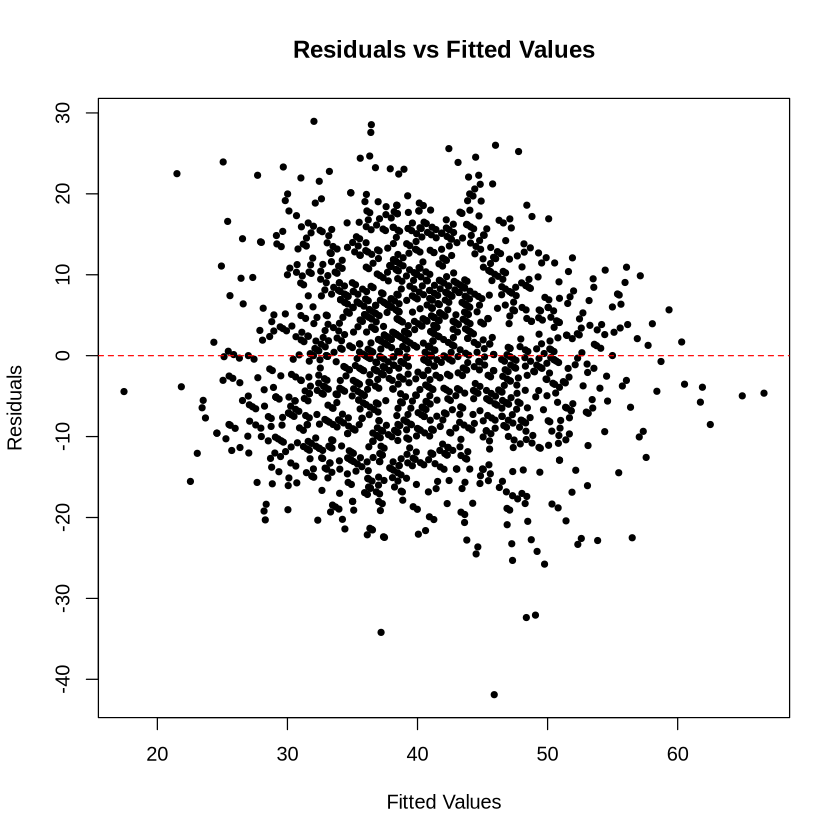

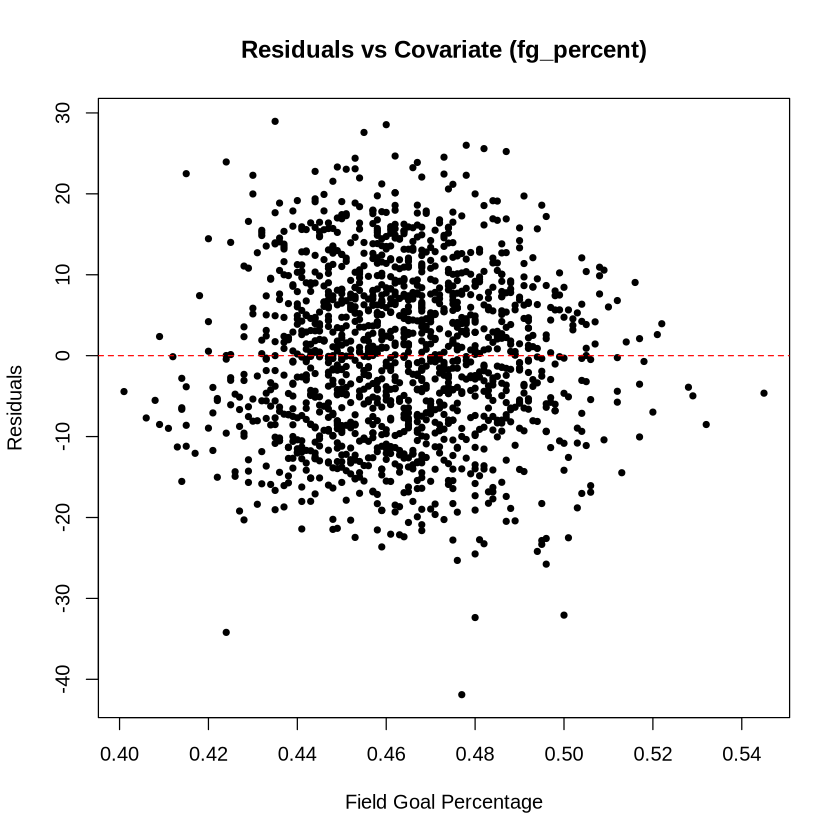

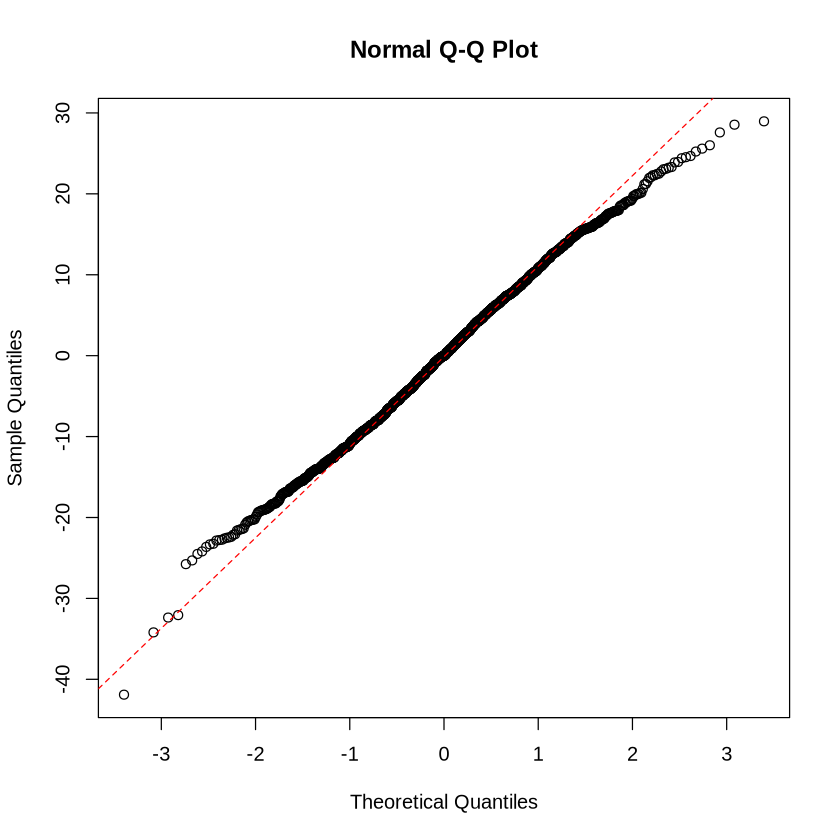

In [15]:
residuals <- resid(reg_full)
fitted_vals <- fitted(reg_full)

# 1. Plot: Residuals against Fitted Values
plot(fitted_vals, residuals, 
     main = "Residuals vs Fitted Values",
     xlab = "Fitted Values", 
     ylab = "Residuals",
     pch = 20)
abline(h = 0, col = "red", lty = 2)

# 2. Plot: Residuals against a Covariate (using fg_percent as an example)
plot(data$fg_percent, residuals, 
     main = "Residuals vs Covariate (fg_percent)",
     xlab = "Field Goal Percentage", 
     ylab = "Residuals",
     pch = 20)
abline(h = 0, col = "red", lty = 2)

# 3. Plot: Normal Quantile Plot
qqnorm(residuals)
qqline(residuals, col = "red", lty = 2)


### 1. Linearity
To assess the linearity assumption, we will examine the Residuals vs Fitted Values plot. Under the model assumptions, the residuals should be independent of the fitted values and scatter randomly without showing any obvious pattern. In our plot, the points are dispersed randomly above and below the zero line. There is no distinct pattern visible in the point cloud. This indicates that the relationship between the explanatory variables and seasonal wins is adequately captured by a linear model.

Additionally, the Residuals vs Covariate (fg_percent) plot shows a similar random dispersion. Because the residuals are independent of this key covariate, it further supports that the linear assumption holds for our individual predictors.

### 2. Homoscedasticity 
To assess the constant variance assumption $(\mathrm{Var}(\varepsilon) = \sigma^2)$, we will re-examine the Residuals vs. Fitted Values and Residuals vs. Covariate plots. Under this assumption, we expect a consistent vertical spread of residuals across the range of fitted values. In both plots, the residuals exhibit a relatively uniform spread (approximately between −25 and +30) across the horizontal axis. There is no evident “fan” or “funnel” shape indicating increasing or decreasing variance. Therefore, the assumption of homoscedasticity appears to be satisfied.

### 3. Normality of Errors
In our plot, the vast majority of the residuals align nearly perfectly with the straight line. While there are a few minor deviations in the extreme bottom-left tail, the overall linear trend is extremely strong. Therefore, we conclude that the normality assumption is satisfied and will not impact the validity of our hypothesis tests.

### 4. Independence of Observations (IID Check)
Linear regression assumes that error terms are Independent and Identically Distributed (IID). While our diagnostics confirm the residuals are identically distributed, they are not perfectly independent. Because our dataset tracks the same NBA franchises over multiple seasons, plotting sequential residuals ($e_{i+1}$ against $e_i$) revealed a positive linear trend, indicating serial correlation (autocorrelation). A team's underlying quality carries over, meaning model errors are associated from year to year. However, because models that account for autocorrelation, such as autoregressive models, are outside the scope of STAT 306, we acknowledge this limitation and proceed with interpreting our standard multiple linear regression model.

## Hypothesis Test

In [21]:
# Standardizing the Covariates so that they all are on the same scale for comparison purposes
data_std <- data |>
  mutate(across(c(pts_per_game, ast_per_game, fg_percent, 
                  stl_per_game, blk_per_game, trb_per_game), scale))

# Fit the FULL model on the standardized data to hold all metrics constant
reg_full_std <- lm(w ~ pts_per_game + ast_per_game + fg_percent + 
                     stl_per_game + blk_per_game + trb_per_game, data = data_std)

# Print the standardized full model
summary(reg_full_std)

# Manual t-Test for Offensive and Defensive Metrics: fg_percent and trb_per_game as Proxies
beta_fg <- coef(reg_full_std)["fg_percent"]
beta_trb <- coef(reg_full_std)["trb_per_game"]

# Extracting variances and covariance from the variance-covariance matrix
vcov_mat <- vcov(reg_full_std)
var_fg <- vcov_mat["fg_percent", "fg_percent"]
var_trb <- vcov_mat["trb_per_game", "trb_per_game"]
cov_fg_trb <- vcov_mat["fg_percent", "trb_per_game"]

# Calculating Standard Error of the difference
se_diff <- sqrt(var_fg + var_trb - 2 * cov_fg_trb)

# Calculate the t-statistic
t_stat <- (beta_fg - beta_trb) / se_diff

df <- df.residual(reg_full_std)
p_value <- 2 * pt(-abs(t_stat), df)

cat(sprintf("The p-value is %.4f\n", p_value))


Call:
lm(formula = w ~ pts_per_game + ast_per_game + fg_percent + stl_per_game + 
    blk_per_game + trb_per_game, data = data_std)

Residuals:
    Min      1Q  Median      3Q     Max 
-41.897  -7.680   0.008   7.414  28.962 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  40.04511    0.27163 147.426  < 2e-16 ***
pts_per_game -2.99650    0.49382  -6.068 1.65e-09 ***
ast_per_game -1.38426    0.45359  -3.052  0.00232 ** 
fg_percent    8.60063    0.43983  19.555  < 2e-16 ***
stl_per_game  0.07067    0.29037   0.243  0.80774    
blk_per_game  0.94749    0.28830   3.287  0.00104 ** 
trb_per_game  3.31476    0.33596   9.867  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10.39 on 1456 degrees of freedom
Multiple R-squared:  0.3164,	Adjusted R-squared:  0.3136 
F-statistic: 112.3 on 6 and 1456 DF,  p-value: < 2.2e-16


The p-value is 0.0000


## Analysis of Hypothesis Test Results
To formally address our research question regarding whether offensive or defensive performance has a stronger association with seasonal wins, we must compare the two groups while "holding the other metrics constant."

Per the interim proposal feedback, we selected one representative proxy variable from each group based on the strongest individual predictors in our initial full model: Field Goal Percentage (fg_percent) for offense and Total Rebounds (trb_per_game) for defense. Because these metrics are recorded in entirely different units (decimals versus counts), their raw coefficients cannot be directly compared. To resolve this, we standardized all explanatory variables before fitting the full model. This scaling ensures that the model coefficients represent the change in seasonal wins for a one standard deviation increase in the metric, allowing for a direct and fair comparison of their magnitudes.

We established the following hypotheses to test whether the offensive proxy has a significantly different association with wins than the defensive proxy:

Null Hypothesis ($H_0$): $\beta_{\text{fg\_percent}} - \beta_{\text{trb\_per\_game}} = 0$ (The standardized effects of offensive efficiency and defensive rebounding on wins are equal).

Alternative Hypothesis ($H_A$): $\beta_{\text{fg\_percent}} - \beta_{\text{trb\_per\_game}} \neq 0$ (The standardized effects are significantly different).

To test this, we manually computed the t-statistic for the difference between the two standardized coefficients. The standard error of the difference was derived using the variance covariance matrix of the standardized model, following the formula: $SE(\hat{\beta}_1 - \hat{\beta}_2) = \sqrt{\text{Var}(\hat{\beta}_1) + \text{Var}(\hat{\beta}_2) - 2\text{Cov}(\hat{\beta}_1, \hat{\beta}_2)}$.

Conclusion of the Hypothesis Test:  
The manual t-test comparing these coefficients yielded a **p-value of 0.0000**. Because the p-value is well below our significance level of $\alpha = 0.05$, we firmly reject the null hypothesis. We conclude that, holding all other metrics constant, an improvement in offensive efficiency is associated with a statistically significantly larger increase in regular-season wins compared to a mathematically equivalent improvement in defensive rebounding.